# Task 1: Classification of conditions

In [1]:
from scmlcourse import preprocessing
from pathlib import Path
import scanpy as sc

AnnData object with n_obs × n_vars = 218331 × 15400
    obs: 'library_preparation_protocol', 'condition', 'MOI', 'sgRNA', 'UMI_count', 'NO_SITE', 'ONE_NON-GENE_SITE', 'perturbation', 'perturbation_2'
AnnData object with n_obs × n_vars = 218331 × 14097
    obs: 'library_preparation_protocol', 'condition', 'MOI', 'sgRNA', 'UMI_count', 'NO_SITE', 'ONE_NON-GENE_SITE', 'perturbation', 'perturbation_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
outlier
False    212679
True    

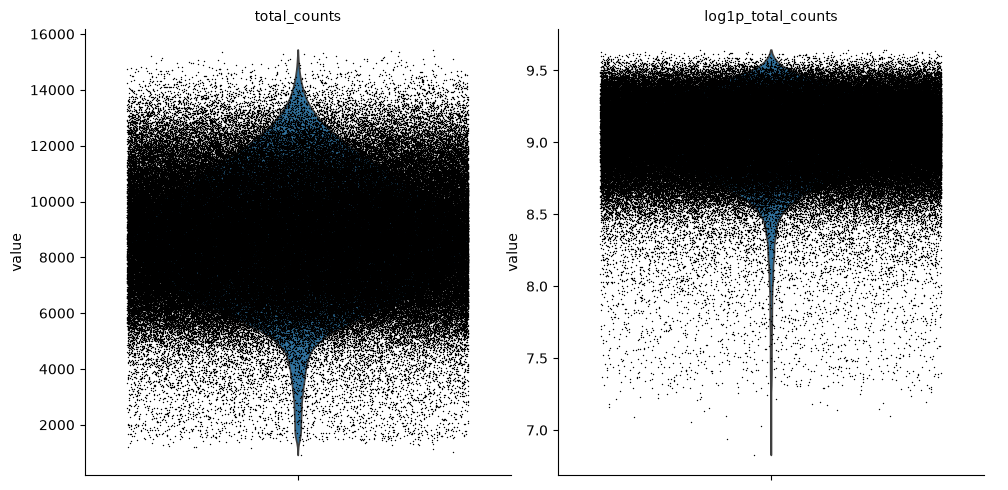

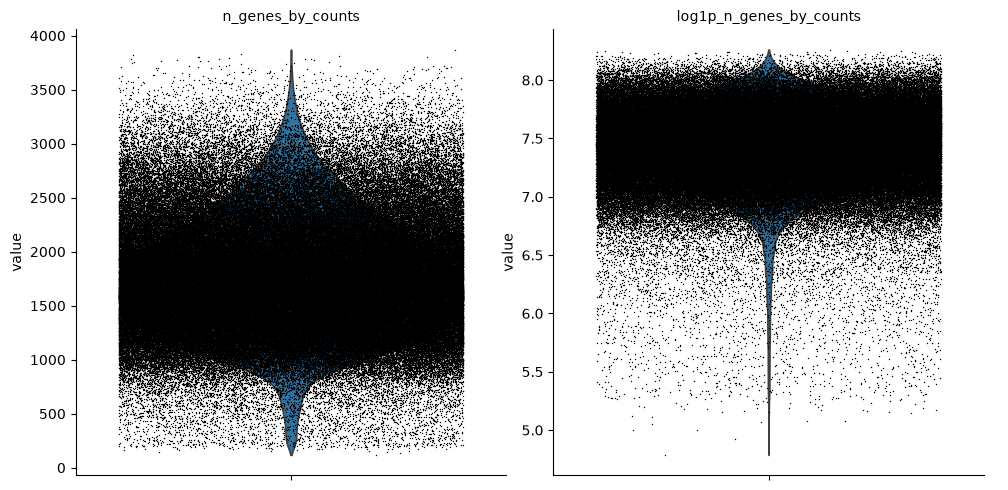

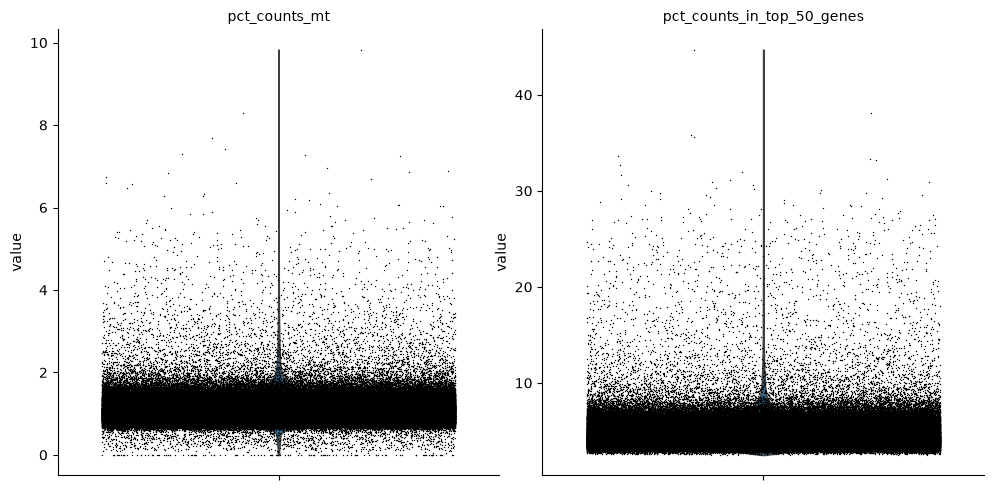

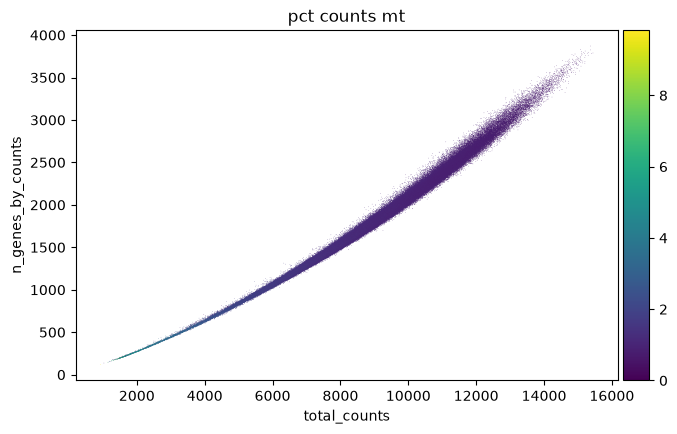

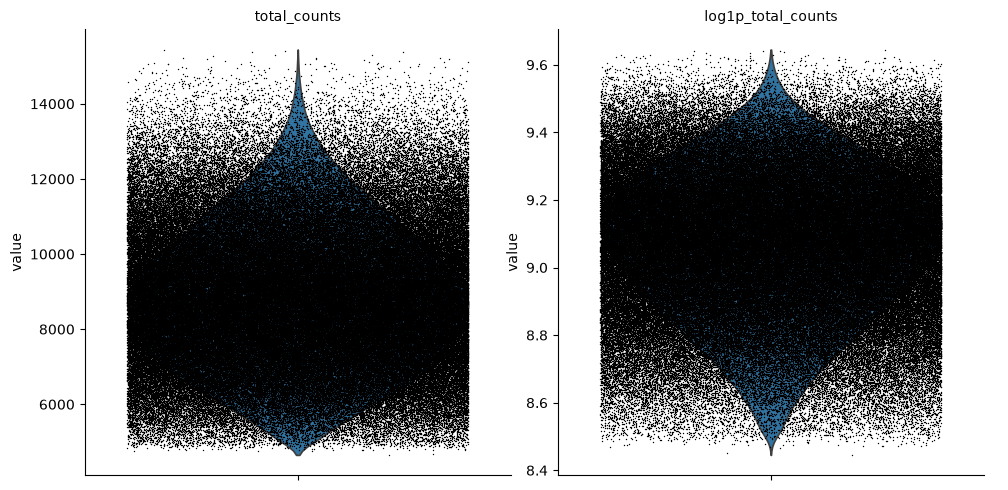

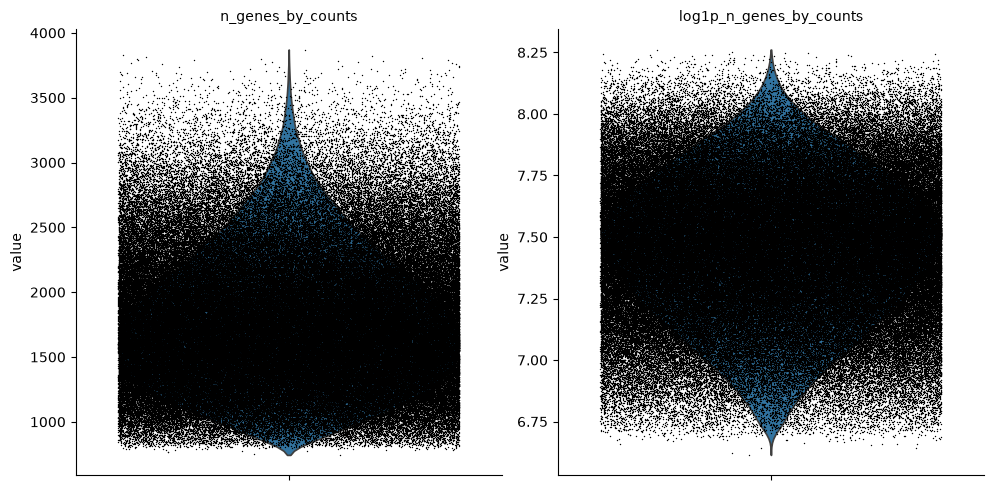

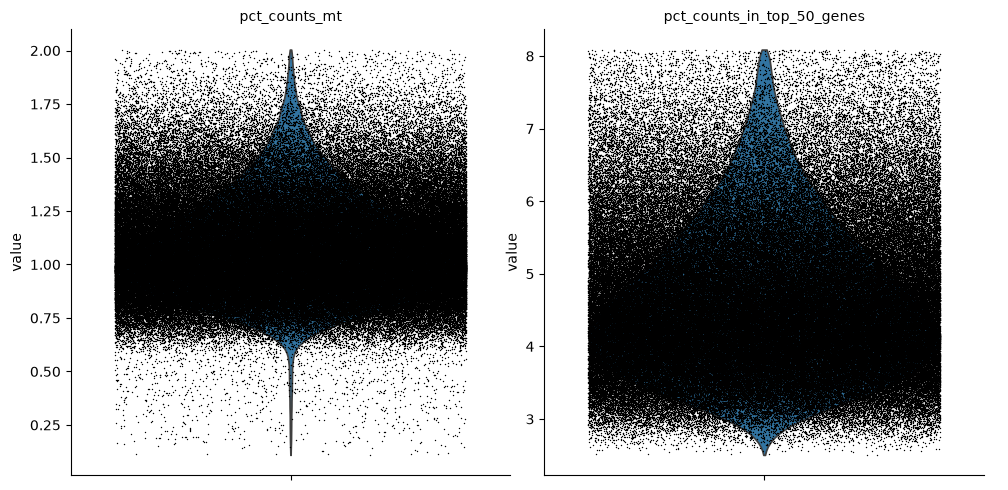

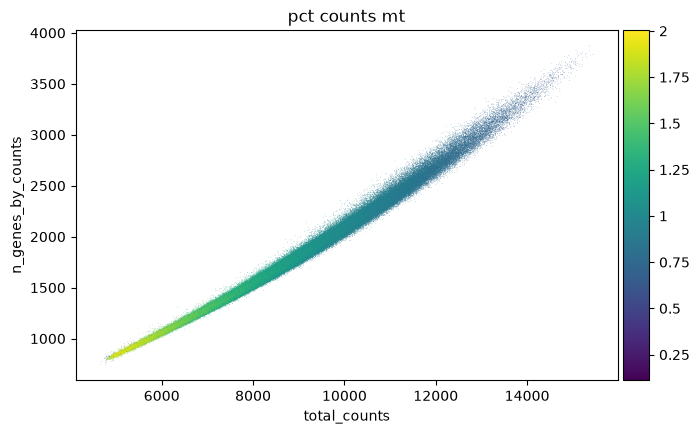

In [13]:
data_dir = Path("../../data/").resolve()
adata = preprocessing.load_raw_adata(data_dir, metadata_path=data_dir/"RNA_metadata.csv", n_chunks=None, out_path=data_dir/"imported_data.h5ad")
adata = preprocessing.run_qc(adata=adata, plots_dir=Path("../plots/qc").resolve(), out_path=data_dir/"qced_data.h5ad", min_genes=20)

In [14]:
adata = preprocessing.preprocess(adata)

In [15]:
adata

AnnData object with n_obs × n_vars = 212679 × 14097
    obs: 'library_preparation_protocol', 'condition', 'MOI', 'sgRNA', 'UMI_count', 'NO_SITE', 'ONE_NON-GENE_SITE', 'perturbation', 'perturbation_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'outlier'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [16]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_validate, train_test_split
from sklearn.metrics import get_scorer_names
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

import pandas as pd
import seaborn as sns
import numpy as np
get_scorer_names()

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'd2_brier_score',
 'd2_log_loss_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighte

In [17]:
X = adata.X[:,adata.var["highly_variable"].to_numpy()]
y = adata.obs["condition"]
X.shape, y.shape
#x_train, x_test, y_train, y_test = train_test_split(X,y, test_size=0.1, shuffle=True, stratify=y)

((212679, 2490), (212679,))

In [18]:
def score_cv(estimator, X,y, scoring = ["accuracy", "average_precision", "f1_macro",]):
    scores = pd.DataFrame(cross_validate(estimator, X,y, scoring=scoring))
    return scores

In [19]:
classifier = LogisticRegression()

scores = score_cv(classifier, X,y)
print(scores)

/home/ntbiotech/Nextcloud/Documents/seminars/scMachineLearning/project/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/ntbiotech/Nextcloud/Documents/seminars/scMachineLearning/project/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You 

    fit_time  score_time  test_accuracy  test_average_precision  test_f1_macro
0  10.192202    0.484967       0.721130                0.766953       0.718440
1  10.582731    0.492213       0.721530                0.762101       0.717720
2  10.533234    0.390274       0.726396                0.771417       0.722855
3  10.546720    0.475552       0.715512                0.755987       0.712143
4  10.187111    0.441149       0.716257                0.757036       0.711783


In [20]:
classifier = RandomForestClassifier(max_depth=10, min_samples_split=10, n_estimators=50)
scores = score_cv(classifier, X,y)
print(scores)

   fit_time  score_time  test_accuracy  test_average_precision  test_f1_macro
0  5.440852    0.727664       0.467627                0.675514       0.331864
1  5.483384    0.730212       0.464266                0.667333       0.322952
2  5.446823    0.730888       0.470613                0.668957       0.337721
3  5.232625    0.662369       0.464595                0.651905       0.330385
4  5.441578    0.689809       0.467662                0.653847       0.330572
